# Let's reuse the content

This notebook shows how to reuse the text extracted from the [Recolección de páginas web. Temáticas ](https://datosabiertos.bne.es/catalogo/dataset/recoleccion-de-paginas-web-tematicas1). In particular, this notebook computes the frequency distribution of the words included in the title column.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
import string
import pandas as pd

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### We open the CSV file using the URL of the dataset

In [6]:
# assigning url to a variable
url="https://www.bne.es/media/datosgob/awe/tematicas-UTF8.csv"

#path = "data/tematicas-UTF8.csv"

# passing parameter to the function
data =pd.read_csv(url,sep=';')
print(data)

                                  Prefijo_de_recolección  \
0                   Bellas Artes y Cartografía (BNEBBAA)   
1                   Bellas Artes y Cartografía (BNEBBAA)   
2                   Bellas Artes y Cartografía (BNEBBAA)   
3                   Bellas Artes y Cartografía (BNEBBAA)   
4                   Bellas Artes y Cartografía (BNEBBAA)   
...                                                  ...   
43036                          Videojuegos (VIDEOJUEGOS)   
43037  25/06/2024 - OW: No se visualizan algunas imág...   
43038  27/06/2024 - Modificamos la profundidad de rut...   
43039  03/07/2024 - Recurso recolectado. Modificamos ...   
43040                          Videojuegos (VIDEOJUEGOS)   

                                                  Título  \
0      "Asociación Fotográfica ""Objetivo Daganzo"" A...   
1      2024, Almansa en 366 calles – Un proyecto del ...   
2                      Agrupación Acuarelistas de Aragón   
3             Agrupación Astronómica Je

In [8]:
# Get column names
column_names = data.columns
print(column_names)

Index(['Prefijo_de_recolección', 'Título', 'Semilla', 'URL_adicionales',
       'Estado', 'Tipo_de_recolección', 'Frecuencia_', 'Profundidad', 'Tamaño',
       'Palabras_clave', 'Materia', 'Notas_técnicas',
       'Modificaciones_de_la_URL', 'Creado_en'],
      dtype='object')


#### Now we concatenate the text provided by the column Description

In [11]:
description = data["Título"]
text = description.str.cat(sep=' ')
#print(text)

### We create split the text into tokens

In [12]:
text_tokens = word_tokenize(text)

### We can improve the stopwords list with our own words

In [19]:
stop_words = stopwords.words('spanish')
print(len(stop_words))
stop_words = stopwords.words('spanish') + list(string.punctuation)
print(len(stop_words))
stop_words.extend(['...', ',,', '-', '–','“','”','’',"''",'https', 'http','``'])
print(len(stop_words))

313
345
356


In [20]:
filtered_words = [word.lower() for word in text_tokens if word.lower() not in stop_words]
#print(filtered_words)

### We can compute the frequency distribution

A frequency distribution records the number of times each outcome of an experiment has occurred. For example, a frequency distribution could be used to record the frequency of each word type in a document.


In [21]:
fdist = FreqDist(filtered_words)
print(fdist)

<FreqDist with 30173 samples and 111543 outcomes>


In [22]:
fdist.most_common(10)

[('twitter', 4135),
 ('nacional', 1366),
 ('biblioteca', 1290),
 ('españa', 1187),
 ('asociación', 764),
 ('revista', 651),
 ('festival', 561),
 ('youtube', 532),
 ('madrid', 447),
 ('mujeres', 408)]

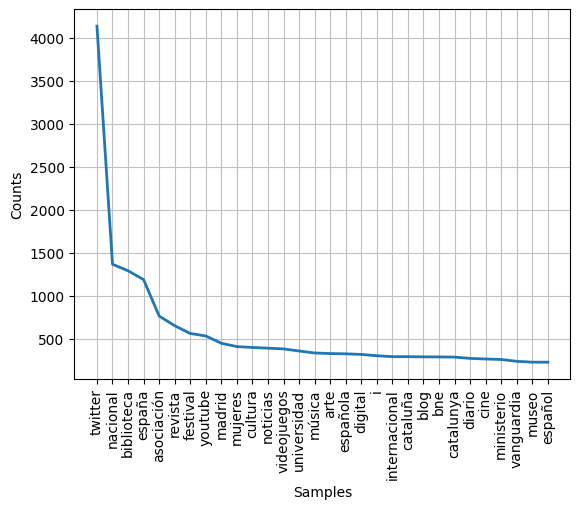

In [23]:
# Frequency Distribution Plot
fdist.plot(30)
plt.savefig('words.png')
plt.show()